<a href="https://colab.research.google.com/github/dhanalakshmirose/Healthcare-Data-Analysis/blob/main/Healthcare_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

 1. LOAD DATA


In [7]:
df = pd.read_csv('insurance.csv')
print(df.head())
print(df.info())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None


 2. DATA CLEANING CHECKS

In [8]:
print("\nMissing values:\n", df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after cleaning:", df.shape)
print(df.describe())


Missing values:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
Duplicate rows: 1
Shape after cleaning: (1337, 7)
               age          bmi     children       charges
count  1337.000000  1337.000000  1337.000000   1337.000000
mean     39.222139    30.663452     1.095737  13279.121487
std      14.044333     6.100468     1.205571  12110.359656
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.290000     0.000000   4746.344000
50%      39.000000    30.400000     1.000000   9386.161300
75%      51.000000    34.700000     2.000000  16657.717450
max      64.000000    53.130000     5.000000  63770.428010


 3. DISTRIBUTIONS (plot 1)

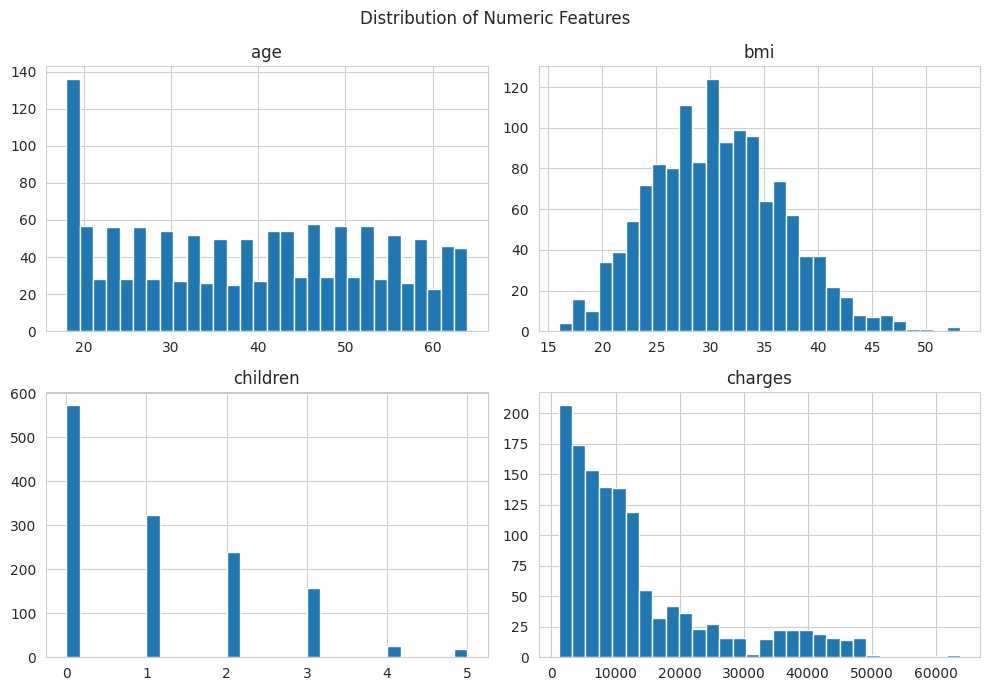


Skewness:
 age        0.054781
bmi        0.283914
charges    1.515391
dtype: float64


In [9]:
df[['age', 'bmi', 'children', 'charges']].hist(bins=30, figsize=(10, 7))
plt.suptitle("Distribution of Numeric Features")
plt.tight_layout()
plt.show()
print("\nSkewness:\n", df[['age', 'bmi', 'charges']].skew())

4. GROUP COMPARISONS (mean, median, count)

In [10]:
for col in ['smoker', 'sex', 'region']:
    print(f"\nCharges by {col}:")
    print(df.groupby(col)['charges'].agg(['mean', 'median', 'count']))


Charges by smoker:
                mean       median  count
smoker                                  
no       8440.660307   7345.72660   1063
yes     32050.231832  34456.34845    274

Charges by sex:
                mean     median  count
sex                                   
female  12569.578844  9412.9625    662
male    13974.998864  9377.9047    675

Charges by region:
                   mean        median  count
region                                      
northeast  13406.384516  10057.652025    324
northwest  12450.840844   8976.977250    324
southeast  14735.411438   9294.131950    364
southwest  12346.937377   8798.593000    325


Plot 2: charges by smoker

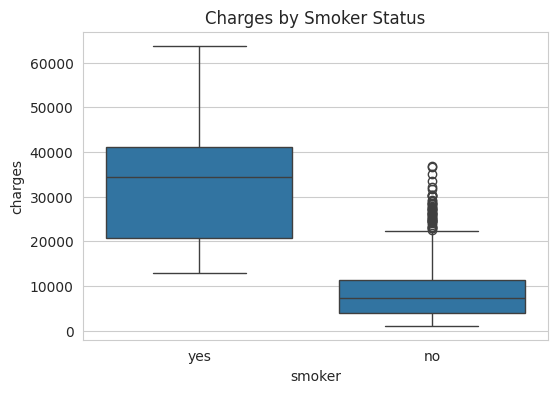

In [11]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='smoker', y='charges', data=df)
plt.title("Charges by Smoker Status")
plt.show()

Plot 3: average charges by region

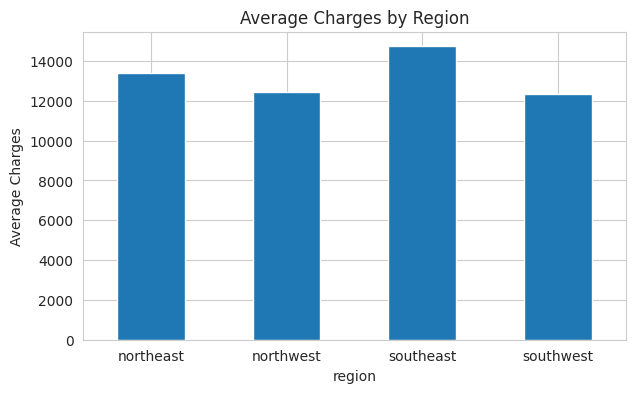

In [12]:
plt.figure(figsize=(7, 4))
df.groupby('region')['charges'].mean().plot(kind='bar')
plt.ylabel("Average Charges")
plt.title("Average Charges by Region")
plt.xticks(rotation=0)
plt.show()


Plot 4: sex split by smoker

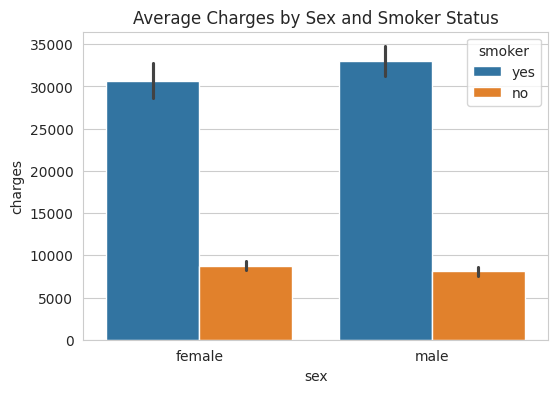

In [13]:
plt.figure(figsize=(6, 4))
sns.barplot(x='sex', y='charges', hue='smoker', data=df)
plt.title("Average Charges by Sex and Smoker Status")
plt.show()

5. CORRELATION

In [14]:
corr = df[['age', 'bmi', 'children', 'charges']].corr()
print("\nCorrelation with charges:\n", corr['charges'].sort_values(ascending=False))


Correlation with charges:
 charges     1.000000
age         0.298308
bmi         0.198401
children    0.067389
Name: charges, dtype: float64


Plot 5: heatmap

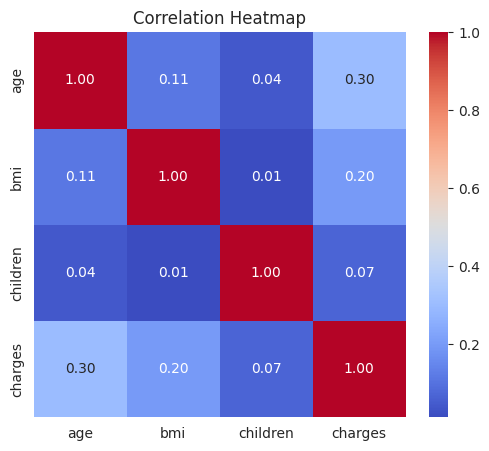

In [15]:
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

6. RELATIONSHIPS SPLIT BY SMOKER

   Plot 6: age vs charges

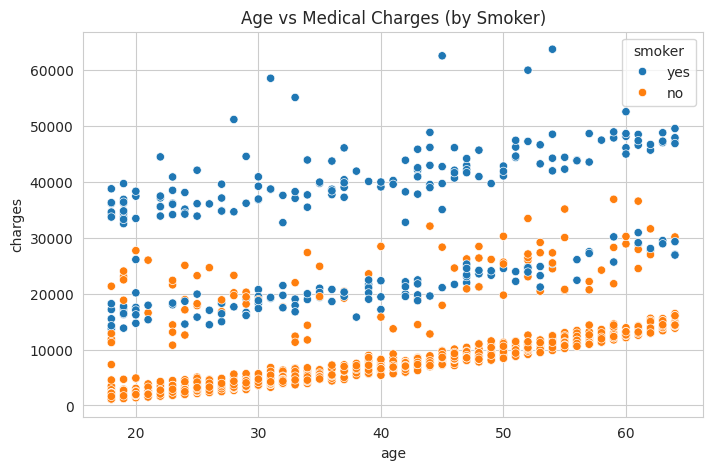

In [16]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='age', y='charges', hue='smoker', data=df)
plt.title("Age vs Medical Charges (by Smoker)")
plt.show()


Plot 7: bmi vs charges

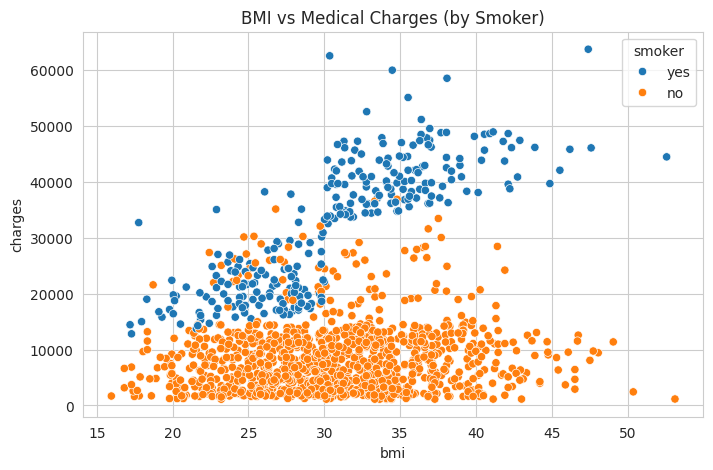

In [17]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df)
plt.title("BMI vs Medical Charges (by Smoker)")
plt.show()

7. BMI CATEGORIES

In [19]:
df['bmi_category'] = pd.cut(df['bmi'],
                            bins=[0, 18.5, 25, 30, 100],
                            labels=['Underweight', 'Normal', 'Overweight', 'Obese'])

print("\nMedian charges: smoker x BMI category:")
print(df.groupby(['smoker', 'bmi_category'], observed=True)['charges'].median().unstack())


Median charges: smoker x BMI category:
bmi_category  Underweight       Normal  Overweight         Obese
smoker                                                          
no             4249.32355   6669.48005   7046.7222   8100.094325
yes           15006.57945  19479.90370  21348.7060  40918.314500


Plot 8: boxplot by BMI category and smoker

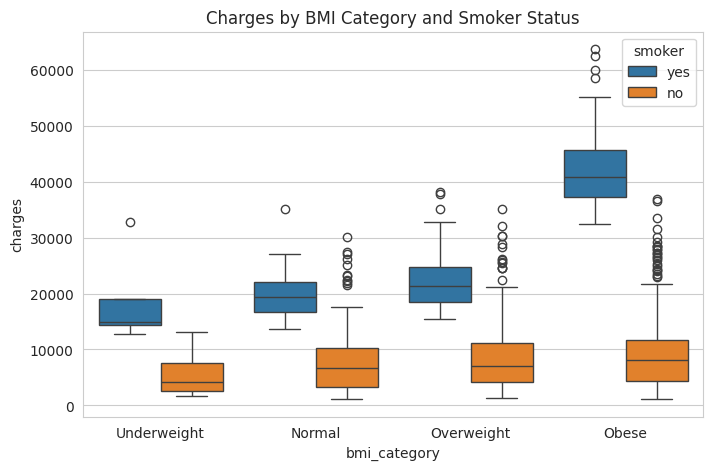

In [20]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='bmi_category', y='charges', hue='smoker', data=df)
plt.title("Charges by BMI Category and Smoker Status")
plt.show()

8. CONSISTENCY CHECK: does the smoker effect hold in every group?

In [21]:
by_region = df.groupby(['region', 'smoker'])['charges'].median().unstack()
by_sex = df.groupby(['sex', 'smoker'])['charges'].median().unstack()
print("\nMedian charges by region and smoker:\n", by_region)
print("\nMedian charges by sex and smoker:\n", by_sex)
smoker_higher_everywhere = ((by_region['yes'] > by_region['no']).all()
                            and (by_sex['yes'] > by_sex['no']).all())


Median charges by region and smoker:
 smoker             no           yes
region                             
northeast  8342.90875  28101.333050
northwest  7259.23205  27488.996475
southeast  6652.52880  37484.449300
southwest  7348.14200  35165.256500

Median charges by sex and smoker:
 smoker           no         yes
sex                            
female  7639.417450  28950.4692
male    6986.101975  36085.2190


 9. KEY INSIGHTS

In [22]:
smoker = df[df['smoker'] == 'yes']['charges']
nonsmoker = df[df['smoker'] == 'no']['charges']
ratio = smoker.mean() / nonsmoker.mean()
age_corr = df['age'].corr(df['charges'])
bmi_corr_smoker = df[df['smoker'] == 'yes']['bmi'].corr(smoker)
bmi_corr_non = df[df['smoker'] == 'no']['bmi'].corr(nonsmoker)
sex_median = df.groupby('sex')['charges'].median()

In [23]:
print("\n================ KEY INSIGHTS ================")
print(f"1. Smokers pay ~{ratio:.1f}x more on average "
      f"(median {smoker.median():,.0f} vs {nonsmoker.median():,.0f}).")
print(f"2. Smokers have higher median charges in every region and for both sexes: "
      f"{smoker_higher_everywhere}.")
print(f"3. Charges rise with age (correlation = {age_corr:.2f}).")
print(f"4. BMI matters mainly for smokers: correlation {bmi_corr_smoker:.2f} "
      f"for smokers vs {bmi_corr_non:.2f} for non-smokers.")
print(f"5. Male and female median charges are almost the same "
      f"({sex_median['male']:,.0f} vs {sex_median['female']:,.0f}).")
print("6. Regional averages differ only slightly.")
print("\nLIMITATIONS: association not causation; no medical history; "
      "charges are skewed, so medians are more reliable than means.")
print("NEXT STEPS: build a regression model to predict charges.")


================ KEY INSIGHTS ================
1. Smokers pay ~3.8x more on average (median 34,456 vs 7,346).
2. Smokers have higher median charges in every region and for both sexes: True.
3. Charges rise with age (correlation = 0.30).
4. BMI matters mainly for smokers: correlation 0.81 for smokers vs 0.08 for non-smokers.
5. Male and female median charges are almost the same (9,378 vs 9,413).
6. Regional averages differ only slightly.

LIMITATIONS: association not causation; no medical history; charges are skewed, so medians are more reliable than means.
NEXT STEPS: build a regression model to predict charges.
